# Tutorial 3: Sparse DM Grids & Negative DM Searches

In this tutorial, we explore two advanced capabilities added to DMT:
1. **Sparse DM Grids**: Eliminating redundant DM trials caused by intra-channel dispersion smearing.
2. **Negative DM Trials**:


## 1. The Physics of Intra-Channel Dispersion Smearing

In any filterbank, each channel has a finite bandwidth $\Delta \nu = \frac{B}{N_{\text{chans}}}$.

Within a single channel of width $\Delta \nu$ centered at frequency $\nu$, dispersion delays the bottom of the channel relative to the top by the **intra-channel smearing time**:

$$\Delta t_{\text{smear}} \approx 2 \mathcal{D} \cdot \text{DM} \cdot \nu^{-3} \Delta \nu$$

### Why Dense Linear Grids are Wasteful at High DM
Notice that $\Delta t_{\text{smear}}$ grows linearly with $\text{DM}$ and inversely with $\nu^3$.
At low DM, $\Delta t_{\text{smear}} < t_{\text{samp}}$, so fine 1-sample DM spacing is required.
However, at high DM, $\Delta t_{\text{smear}} \gg t_{\text{samp}}$. A pulse is smeared over 10, 20, or 50 samples *inside each individual channel*!

Searching with fine uniform steps $\delta(\text{DM})$ produces massive redundant overlap, wasting memory and CPU/GPU compute cycles.

### Sparse Grids in DMT
DMT allows passing custom non-linear delay or DM grids via:
- `dt_grid` / `dt_arr`: Explicit sample delay trials $[d_0, d_1, d_2, \dots]$.
- `dm_grid` / `dm_arr`: Explicit physical DM trials in $\text{pc}\,\text{cm}^{-3}$.

DMT's internal planner automatically sorts, uniques, and maps arbitrary sparse grids into an optimal tree structure!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dmtlib import FDMTPlan, FDMTCPU

f_min = 800.0    # Low-frequency band (high dispersion smearing)
f_max = 1200.0
nchans = 256
nsamps = 1024
tsamp = 1e-3

# 1. Standard dense linear grid: dt in [0, 500] with step 1
plan_dense = FDMTPlan(
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=nsamps,
    tsamp=tsamp,
    dt_max=500,
    dt_min=0,
    dt_step=1,
)

# 2. Optimal sparse grid: geometric / quadratic spacing matching smearing width
# Fine steps at low delay, geometrically expanding steps at high delay
dt_sparse = np.unique(np.round(np.geomspace(1, 501, 120) - 1).astype(int))

plan_sparse = FDMTPlan(
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=nsamps,
    tsamp=tsamp,
    dt_grid=dt_sparse,
)

print("Grid Comparison:")
print(f"  Dense linear grid trials:  {len(plan_dense.dt_grid_final)}")
print(f"  Sparse adaptive grid trials: {len(plan_sparse.dt_grid_final)}")
print(f"  Reduction in output trials:  {len(plan_dense.dt_grid_final) / len(plan_sparse.dt_grid_final):.2f}x")


Grid Comparison:
  Dense linear grid trials:  501
  Sparse adaptive grid trials: 82
  Reduction in output trials:  6.11x


Plan buffer memory:
  Dense plan:  970.7 KB
  Sparse plan: 716.9 KB (26.2% reduction)


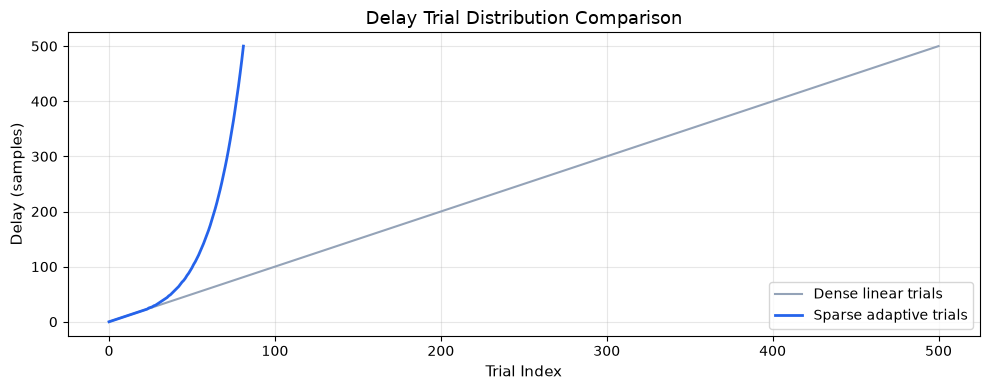

In [2]:
# Compare tree memory consumption
mem_dense_kb = plan_dense.container.memory_usage / 1024.0
mem_sparse_kb = plan_sparse.container.memory_usage / 1024.0

print(f"Plan buffer memory:")
print(f"  Dense plan:  {mem_dense_kb:.1f} KB")
print(f"  Sparse plan: {mem_sparse_kb:.1f} KB ({(1.0 - mem_sparse_kb / mem_dense_kb) * 100:.1f}% reduction)")

# Plot trial spacing comparison
plt.figure(figsize=(10, 4))
plt.plot(plan_dense.dt_grid_final, label="Dense linear trials", color="#94a3b8", lw=1.5)
plt.plot(plan_sparse.dt_grid_final, label="Sparse adaptive trials", color="#2563eb", lw=2)
plt.title("Delay Trial Distribution Comparison", fontsize=13)
plt.xlabel("Trial Index", fontsize=11)
plt.ylabel("Delay (samples)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 2. Negative DM Searches

DMT natively supports negative DMs and negative delay ranges by specifying `dt_min < 0` (or `dm_min < 0`).


In [3]:
# Setup a bipolar plan searching symmetric negative and positive delays
dt_max = 64
dt_min = -64

plan_bipolar = FDMTPlan(
    f_min=1200.0,
    f_max=1600.0,
    nchans=128,
    nsamps=512,
    tsamp=1e-3,
    dt_max=dt_max,
    dt_min=dt_min,
    dt_step=1,
    mode="valid",
)

print(f"Bipolar plan created:")
print(f"  dt range: [{plan_bipolar.dt_min}, {plan_bipolar.dt_max}]")
print(f"  Total delay trials: {len(plan_bipolar.dt_grid_final)}")
print(f"  First 5 trials: {plan_bipolar.dt_grid_final[:5]}")
print(f"  Last 5 trials:  {plan_bipolar.dt_grid_final[-5:]}")


Bipolar plan created:
  dt range: [-64, 64]
  Total delay trials: 129
  First 5 trials: [-64 -63 -62 -61 -60]
  Last 5 trials:  [60 61 62 63 64]


Recovered chirp peak at trial dt = 32 (Injected: -30)


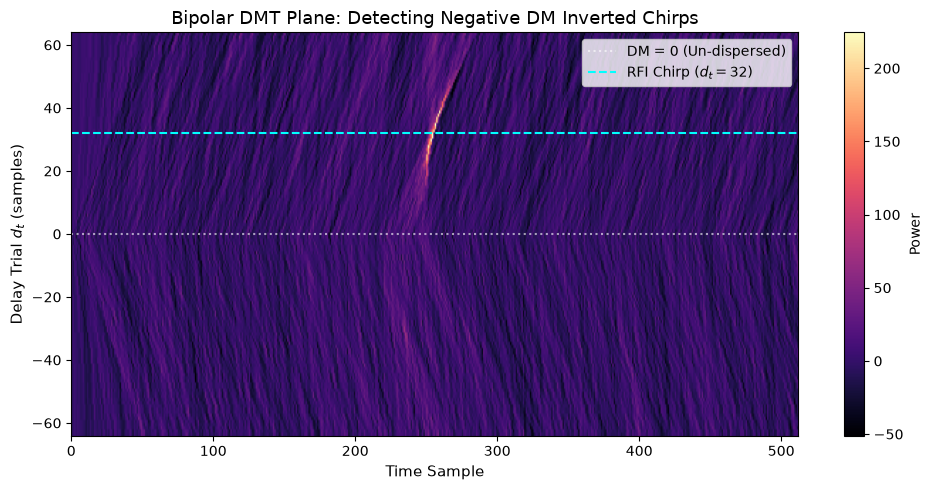

In [4]:
# Simulate an RFI chirp with inverted sweep (negative effective delay)
waterfall_rfi = np.random.normal(loc=0.0, scale=1.0, size=(128, 512)).astype(np.float32)

# Inject inverted chirp: arrives at low frequency FIRST, high frequency LAST
target_delay = -30
for c in range(128):
    frac = c / 127.0
    # Negative sweep
    sample = int(250 + target_delay * frac)
    if 0 <= sample < 512:
        waterfall_rfi[c, sample] += 3.0

# Dedisperse using FDMTCPU
fdmt_bipolar = FDMTCPU(
    f_min=1200.0,
    f_max=1600.0,
    nchans=128,
    nsamps=512,
    tsamp=1e-3,
    dt_max=dt_max,
    dt_min=dt_min,
    dt_step=1,
    mode="valid",
)

dmt_bipolar = fdmt_bipolar.execute(waterfall_rfi)

# Locate peak in negative DM territory
peak_dt_idx, peak_t = np.unravel_index(np.argmax(dmt_bipolar), dmt_bipolar.shape)
recovered_dt = plan_bipolar.dt_grid_final[peak_dt_idx]

print(f"Recovered chirp peak at trial dt = {recovered_dt} (Injected: {target_delay})")

# Plot the bipolar DMT plane
plt.figure(figsize=(10, 5))
plt.imshow(
    dmt_bipolar,
    aspect="auto",
    origin="lower",
    extent=[0, dmt_bipolar.shape[1], plan_bipolar.dt_grid_final[0], plan_bipolar.dt_grid_final[-1]],
    cmap="magma",
)
plt.axhline(0, color="white", linestyle=":", alpha=0.6, label="DM = 0 (Un-dispersed)")
plt.axhline(recovered_dt, color="cyan", linestyle="--", label=f"RFI Chirp ($d_t={recovered_dt}$)")
plt.title("Bipolar DMT Plane: Detecting Negative DM Inverted Chirps", fontsize=13)
plt.xlabel("Time Sample", fontsize=11)
plt.ylabel("Delay Trial $d_t$ (samples)", fontsize=11)
plt.colorbar(label="Power")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Summary

You have explored:
- Why dispersion smearing makes dense linear grids redundant at high DM.
- How to pass custom sparse grids (`dt_grid`, `dm_grid`) to save memory and processing time.
- How DMT seamlessly supports signed delays $d_t \in [d_{\min}, d_{\max}]$.

In **Tutorial 4**, we conduct a side-by-side architectural and performance comparison of **FDMT vs. DDMT**!
